In [26]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.stats import qmc
from tqdm.auto import tqdm

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8,8)

import anndata as ad
import pandas as pd
import numpy as np
import mingl as mg
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import time

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
#Import Neighborhood Functions and Code
cellhier_path = r'z:\MINGLE\Code\cellhier'
sys.path.append(cellhier_path)
from general import *
from plot_john_2 import *
from knn_graph_neighborhood2 import *  # Imports everything

In [58]:
def simulate_tissue(
    organization_mixing_width=120,#slow=250, medium=120, fast=40
    organization_difference=0.30,
    local_weight=0,
    n_passes=3,
    seed=42,
    width=1000,
    height=1000,
    n_cells=5000,
    min_distance=10,
    k=10,
    n_cell_types=12,
):
    """
    Generate one synthetic tissue.

    Returns
    -------
    pandas.DataFrame
        cell_id
        x
        y
        cell_type
        unique_region
        true_organization
    """

    np.random.seed(seed)

    ####################################################
    # Generate coordinates
    ####################################################

    sampler = qmc.Sobol(
        d=2,
        scramble=True,
        seed=seed
    )

    points = sampler.random(n_cells)

    points[:,0] *= width
    points[:,1] *= height

    ####################################################
    # Remove overlapping cells
    ####################################################

    tree = cKDTree(points)

    keep = np.ones(len(points), dtype=bool)

    for i in range(len(points)):

        if not keep[i]:
            continue

        nbrs = tree.query_ball_point(
            points[i],
            min_distance
        )

        nbrs.remove(i)

        keep[nbrs] = False

    points = points[keep]

    ####################################################
    # Dataframe
    ####################################################

    cells = pd.DataFrame({

        "cell_id": np.arange(len(points)),

        "x": points[:,0],

        "y": points[:,1]

    })

    ####################################################
    # Graph
    ####################################################

    tree = cKDTree(points)

    _, neighbors = tree.query(
        points,
        k=k+1
    )

    neighbors = neighbors[:,1:]

    ####################################################
    # Organizations
    ####################################################

    border_x = width/2

    pB = 1/(1+np.exp(

        -(cells.x-border_x)

        /organization_mixing_width

    ))

    cells["organization"] = np.where(

        np.random.rand(len(cells))<pB,

        "B",

        "A"

    )

    ####################################################
    # Templates
    ####################################################

    background = np.random.dirichlet(
        np.ones(n_cell_types)*4
    )

    delta = np.random.normal(
        0,
        organization_difference,
        n_cell_types
    )

    template_A = np.clip(
        background + delta,
        0.001,
        None
    )

    template_B = np.clip(
        background - delta,
        0.001,
        None
    )

    template_A /= template_A.sum()
    template_B /= template_B.sum()

    ####################################################
    # Assignment order
    ####################################################

    cells["cell_type"] = -1

    cells["distance_from_border"] = np.abs(
        cells.x-border_x
    )

    assignment_order = cells.sort_values(
        "distance_from_border",
        ascending=False
    ).cell_id.values

    ####################################################
    # Helper
    ####################################################

    def neighborhood_probability(i):

        nbrs = neighbors[i]

        assigned = cells.iloc[nbrs]

        assigned = assigned[
            assigned.cell_type!=-1
        ]

        if cells.organization.iloc[i]=="A":
            template = template_A.copy()
        else:
            template = template_B.copy()

        if len(assigned)==0:
            return template

        counts = np.bincount(
            assigned.cell_type,
            minlength=n_cell_types+1
        )[1:]

        local = counts/counts.sum()

        probs = (
            (1-local_weight)*template
            +
            local_weight*local
        )

        probs /= probs.sum()

        return probs

    ####################################################
    # Build tissue
    ####################################################

    for _ in range(n_passes):

        for cell in assignment_order:

            probs = neighborhood_probability(cell)

            cells.at[cell,"cell_type"] = np.random.choice(

                np.arange(1,n_cell_types+1),

                p=probs

            )

    ####################################################
    # Final output
    ####################################################

    cells["unique_region"] = 1
    cells["true_organization"] = cells["organization"]

    # Return only the columns needed downstream
    output = cells[[
        "cell_id",
        "x",
        "y",
        "cell_type",
        "unique_region",
        "true_organization"
    ]].copy()

    output.attrs["border_x"] = border_x
    
    return output

In [7]:
sim = simulate_tissue()

sim.head()

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2258120585.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


,cell_id,x,y,cell_type,unique_region,true_organization
0,0,431.029474,814.367972,12,1,A
1,1,961.578793,311.409943,8,1,B
2,2,564.531920,597.834305,11,1,A
3,3,35.047322,26.509271,11,1,A
4,4,238.067276,639.697611,6,1,A


In [53]:
def run_neighborhood_finder(
    cells,
    ks=[5, 10, 20],
    k=10,
    n_neighborhoods=2,
    random_state=0,
):
    """
    Run the CellHier neighborhood finder on a dataframe produced by
    simulate_tissue().

    Returns
    -------
    pandas.DataFrame
        Original dataframe with an added 'Neighborhood' column.
    """

    ####################################################
    # Copy input
    ####################################################

    df = cells.copy()
    cells = cells.copy()

    ####################################################
    # Setup
    ####################################################

    X = "x"
    Y = "y"
    reg = "unique_region"
    cluster_col = "cell_type"

    cells[reg] = cells[reg].astype(str)
    df[reg] = df[reg].astype(str)

    keep_cols = [X, Y, reg, cluster_col]

    ####################################################
    # Dummy encoding
    ####################################################

    cells.reset_index(drop=True, inplace=True)

    cells = pd.concat(
        [cells, pd.get_dummies(cells[cluster_col])],
        axis=1,
    )

    sum_cols = cells[cluster_col].unique()

    values = cells[sum_cols].values

    ####################################################
    # Nearest-neighbor setup
    ####################################################

    n_neighbors = max(ks)

    tissue_group = cells[[X, Y, reg]].groupby(reg)

    exps = list(cells[reg].unique())

    ####################################################
    # Helper function
    ####################################################

    def get_windows(job, n_neighbors):

        start_time, idx, tissue_name, indices = job

        job_start = time.time()

        print(f"Starting: {idx+1}/{len(exps)} : {tissue_name}")

        tissue = tissue_group.get_group(tissue_name)

        to_fit = tissue.loc[indices][[X, Y]].values

        fit = NearestNeighbors(
            n_neighbors=n_neighbors
        ).fit(
            tissue[[X, Y]].values
        )

        distances, neighbors = fit.kneighbors(to_fit)

        args = distances.argsort(axis=1)

        add = np.arange(neighbors.shape[0]) * neighbors.shape[1]

        sorted_indices = neighbors.flatten()[args + add[:, None]]

        neighbors = tissue.index.values[sorted_indices]

        end_time = time.time()

        print(
            f"Finished: {idx+1}/{len(exps)} "
            f"({end_time-job_start:.2f} sec)"
        )

        return neighbors.astype(np.int32)

    ####################################################
    # Build neighborhood graph
    ####################################################

    tissue_chunks = [

        (
            time.time(),
            exps.index(t),
            t,
            a,
        )

        for t, indices in tissue_group.groups.items()

        for a in np.array_split(indices, 1)

    ]

    tissues = [

        get_windows(job, n_neighbors)

        for job in tissue_chunks

    ]

    ####################################################
    # Neighborhood vectors
    ####################################################

    out_dict = {}

    for kk in ks:

        for neighbors, job in zip(tissues, tissue_chunks):

            chunk = np.arange(len(neighbors))

            tissue_name = job[2]

            indices = job[3]

            window = (

                values[
                    neighbors[:, :kk].flatten()
                ]

                .reshape(
                    len(chunk),
                    kk,
                    len(sum_cols),
                )

                .sum(axis=1)

            )

            out_dict[(tissue_name, kk)] = (

                window.astype(np.float16),

                indices,

            )

    ####################################################
    # Assemble windows
    ####################################################

    windows = {}

    for kk in ks:

        window = pd.concat(

            [

                pd.DataFrame(

                    out_dict[(exp, kk)][0],

                    index=out_dict[(exp, kk)][1].astype(int),

                    columns=sum_cols,

                )

                for exp in exps

            ],

            axis=0,

        )

        window = window.loc[cells.index.values]

        window = pd.concat(

            [

                cells[keep_cols],

                window,

            ],

            axis=1,

        )

        windows[kk] = window

    ####################################################
    # Select neighborhood size
    ####################################################

    windows2 = windows[k].copy()

    windows2[cluster_col] = cells[cluster_col]

    ####################################################
    # MiniBatchKMeans
    ####################################################

    neighborhood_name = f"neighborhood{k}"

    km = MiniBatchKMeans(

        n_clusters=n_neighborhoods,

        random_state=random_state,

    )

    labels = km.fit_predict(

        windows2[sum_cols].values

    )

    cells[neighborhood_name] = labels

    ####################################################
    # Convert cluster labels using majority vote
    ####################################################

    # Determine which organization is most common in each cluster
    cluster_to_org = (
        pd.crosstab(
            cells[neighborhood_name],
            df["true_organization"]
        )
        .idxmax(axis=1)
        .to_dict()
    )

    # Convert numerical cluster labels into organization labels
    cells["Neighborhood"] = cells[
        neighborhood_name
    ].map(cluster_to_org)

    ####################################################
    # Merge back
    ####################################################

    new_neighborhoods = cells[
        [
            "x",
            "y",
            "unique_region",
            "Neighborhood",
        ]
    ].copy()

    merged_df = pd.merge(

        df,

        new_neighborhoods,

        on=["x", "y", "unique_region"],

        how="left",

    )

    merged_df.attrs["neighborhood_vectors"] = windows2[sum_cols].values
    
    return merged_df

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate_recovery(df, verbose=True):
    """
    Evaluate neighborhood recovery against the known ground truth.

    Parameters
    ----------
    df : pandas.DataFrame
        Output of run_neighborhood_finder().

    verbose : bool
        Print summary statistics.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    ####################################################
    # True and predicted labels
    ####################################################

    y_true = df["true_organization"]
    y_pred = df["Neighborhood"]

    ####################################################
    # Overall accuracy
    ####################################################

    accuracy = accuracy_score(y_true, y_pred)

    ####################################################
    # Per-organization accuracy
    ####################################################

    accuracy_A = (
        df.loc[df.true_organization == "A", "Neighborhood"] == "A"
    ).mean()

    accuracy_B = (
        df.loc[df.true_organization == "B", "Neighborhood"] == "B"
    ).mean()

    ####################################################
    # Confusion matrix
    ####################################################

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["A", "B"]
    )

    ####################################################
    # Store metrics
    ####################################################

    metrics = {
        "accuracy": accuracy,
        "accuracy_A": accuracy_A,
        "accuracy_B": accuracy_B,
        "confusion_matrix": cm,
        "n_cells": len(df),
    }

    ####################################################
    # Print summary
    ####################################################

    if verbose:

        print(f"Overall Accuracy : {accuracy:.3f}")
        print(f"Accuracy A       : {accuracy_A:.3f}")
        print(f"Accuracy B       : {accuracy_B:.3f}")

        print()

        print("Confusion Matrix")

        print(
            pd.DataFrame(
                cm,
                index=["True A", "True B"],
                columns=["Pred A", "Pred B"],
            )
        )

    return metrics

In [51]:
sim = simulate_tissue(
    organization_difference=0.25,
    local_weight=0.20
)

sim = run_neighborhood_finder(sim)

metrics = evaluate_recovery(sim)

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2258120585.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)
Overall Accuracy : 0.840
Accuracy A       : 0.854
Accuracy B       : 0.827

Confusion Matrix
        Pred A  Pred B
True A    1536     263
True B     313    1493


In [35]:
def parameter_sweep(
    organization_differences,
    local_weights,
    n_passes_list,
    seeds,
    organization_mixing_width=120,
):
    """
    Run a parameter sweep over synthetic tissue generation.

    Returns
    -------
    pandas.DataFrame
        One row per simulation.
    """

    results = []

    total = (
        len(organization_differences)
        * len(local_weights)
        * len(n_passes_list)
        * len(seeds)
    )

    with tqdm(total=total, desc="Parameter Sweep") as pbar:

        for diff in organization_differences:

            for local in local_weights:

                for passes in n_passes_list:

                    for seed in seeds:

                        ####################################################
                        # Simulate tissue
                        ####################################################

                        sim = simulate_tissue(
                            organization_difference=diff,
                            local_weight=local,
                            n_passes=passes,
                            organization_mixing_width=organization_mixing_width,
                            seed=seed,
                        )

                        ####################################################
                        # Recover neighborhoods
                        ####################################################

                        recovered = run_neighborhood_finder(sim)

                        ####################################################
                        # Evaluate
                        ####################################################

                        metrics = evaluate_recovery(
                            recovered,
                            verbose=False,
                        )

                        ####################################################
                        # Save results
                        ####################################################

                        record = {
                            "organization_difference": diff,
                            "local_weight": local,
                            "n_passes": passes,
                            "seed": seed,
                        }

                        record.update(metrics)

                        results.append(record)

                        pbar.update(1)

    return pd.DataFrame(results)

In [ ]:
sweep_results = parameter_sweep(
    organization_differences=[0.15, 0.20, 0.25, 0.30],
    local_weights=[0.0, 0.1, 0.2, 0.3],
    n_passes_list=[1, 2, 3],
    seeds=range(5),
)

Parameter Sweep:   0%|          | 0/240 [00:00<?, ?it/s]C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2258120585.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


Parameter Sweep:   0%|          | 1/240 [00:01<04:18,  1.08s/it]C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2258120585.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)
Parameter Sweep:   1%|          | 2/240 [00:02<04:32,  1.15s/it]

Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2258120585.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)
Parameter Sweep:   1%|▏         | 3/240 [00:03<04:32,  1.15s/it]

...

Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


Parameter Sweep:  99%|█████████▉| 238/240 [09:17<00:05,  2.84s/it]C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2258120585.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


Parameter Sweep: 100%|█████████▉| 239/240 [09:20<00:03,  3.01s/it]C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2258120585.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)
Parameter Sweep: 100%|██████████| 240/240 [09:23<00:00,  2.35s/it]

Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


In [ ]:
sweep_results

,organization_difference,local_weight,n_passes,seed,accuracy,accuracy_A,accuracy_B,confusion_matrix,n_cells
0,0.15,0.0,1,0,0.841617,0.831053,0.852321,"[[1397, 284], [245, 1414]]",3340
1,0.15,0.0,1,1,0.853487,0.859718,0.847277,"[[1526, 249], [272, 1509]]",3556
2,0.15,0.0,1,2,0.835385,0.797921,0.872232,"[[1382, 350], [225, 1536]]",3493
3,0.15,0.0,1,3,0.839251,0.810223,0.869008,"[[1490, 349], [235, 1559]]",3633
4,0.15,0.0,1,4,0.833079,0.833030,0.833128,"[[1372, 275], [271, 1353]]",3271
...,...,...,...,...,...,...,...,...,...
235,0.30,0.3,3,0,0.831437,0.826889,0.836046,"[[1390, 291], [272, 1387]]",3340
236,0.30,0.3,3,1,0.845332,0.859155,0.831555,"[[1525, 250], [300, 1481]]",3556
237,0.30,0.3,3,2,0.831663,0.821016,0.842135,"[[1422, 310], [278, 1483]]",3493
238,0.30,0.3,3,3,0.838426,0.830343,0.846711,"[[1527, 312], [275, 1519]]",3633


In [38]:
def plot_parameter_sweep(results):
    """
    Visualize the results of a parameter sweep.

    Parameters
    ----------
    results : pandas.DataFrame
        Output of parameter_sweep().

    Returns
    -------
    summary : pandas.DataFrame
        Mean and standard deviation for each parameter combination.
    """

    import matplotlib.pyplot as plt

    ####################################################
    # Summarize over seeds
    ####################################################

    summary = (
        results
        .groupby([
            "organization_difference",
            "local_weight",
            "n_passes"
        ])
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_accuracy_A=("accuracy_A", "mean"),
            mean_accuracy_B=("accuracy_B", "mean"),
            n=("accuracy", "size"),
        )
        .reset_index()
    )

    ####################################################
    # Figure 1
    # Heatmap of mean accuracy
    ####################################################

    for passes in sorted(summary.n_passes.unique()):

        subset = summary.query("n_passes == @passes")

        heat = subset.pivot(
            index="local_weight",
            columns="organization_difference",
            values="mean_accuracy"
        )

        plt.figure(figsize=(6,5))

        plt.imshow(
            heat,
            origin="lower",
            aspect="auto",
            vmin=0.5,
            vmax=1.0,
        )

        plt.colorbar(label="Mean Accuracy")

        plt.xticks(
            np.arange(len(heat.columns)),
            np.round(heat.columns,2)
        )

        plt.yticks(
            np.arange(len(heat.index)),
            np.round(heat.index,2)
        )

        plt.xlabel("Organization Difference")

        plt.ylabel("Local Weight")

        plt.title(f"Neighborhood Accuracy (passes={passes})")

        plt.tight_layout()

    ####################################################
    # Figure 2
    # Heatmap of standard deviation
    ####################################################

    for passes in sorted(summary.n_passes.unique()):

        subset = summary.query("n_passes == @passes")

        heat = subset.pivot(
            index="local_weight",
            columns="organization_difference",
            values="std_accuracy"
        )

        plt.figure(figsize=(6,5))

        plt.imshow(
            heat,
            origin="lower",
            aspect="auto",
        )

        plt.colorbar(label="Accuracy SD")

        plt.xticks(
            np.arange(len(heat.columns)),
            np.round(heat.columns,2)
        )

        plt.yticks(
            np.arange(len(heat.index)),
            np.round(heat.index,2)
        )

        plt.xlabel("Organization Difference")

        plt.ylabel("Local Weight")

        plt.title(f"Accuracy Stability (passes={passes})")

        plt.tight_layout()

    ####################################################
    # Figure 3
    # Accuracy vs passes
    ####################################################

    plt.figure(figsize=(7,5))

    pass_summary = (
        summary
        .groupby("n_passes")
        .mean(numeric_only=True)
        .reset_index()
    )

    plt.errorbar(
        pass_summary.n_passes,
        pass_summary.mean_accuracy,
        yerr=pass_summary.std_accuracy,
        marker="o",
        capsize=4,
    )

    plt.xlabel("Number of Assignment Passes")

    plt.ylabel("Mean Accuracy")

    plt.title("Effect of Assignment Passes")

    plt.ylim(0.5,1)

    plt.tight_layout()

    ####################################################
    # Figure 4
    # Accuracy A vs B
    ####################################################

    plt.figure(figsize=(7,5))

    plt.scatter(
        summary.mean_accuracy_A,
        summary.mean_accuracy_B,
        s=70,
    )

    lims = [0.5,1]

    plt.plot(lims, lims, "--", color="gray")

    plt.xlim(lims)

    plt.ylim(lims)

    plt.xlabel("Accuracy A")

    plt.ylabel("Accuracy B")

    plt.title("Bias Between Organizations")

    plt.tight_layout()

    return summary

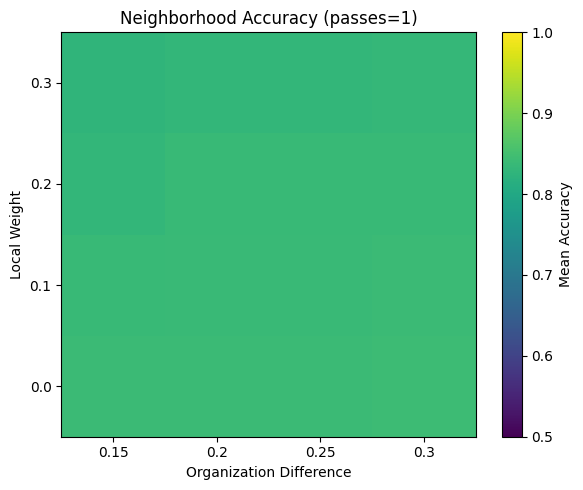

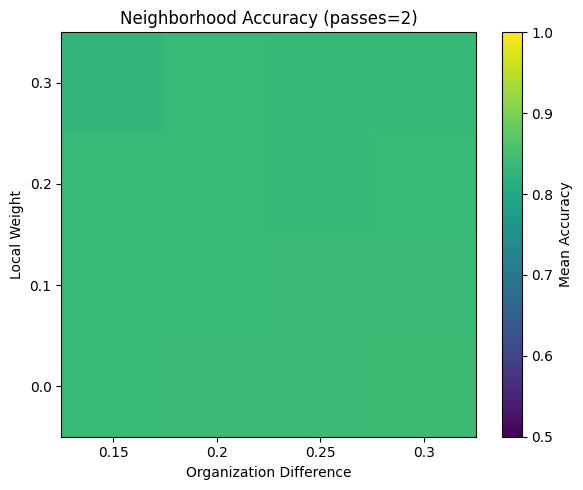

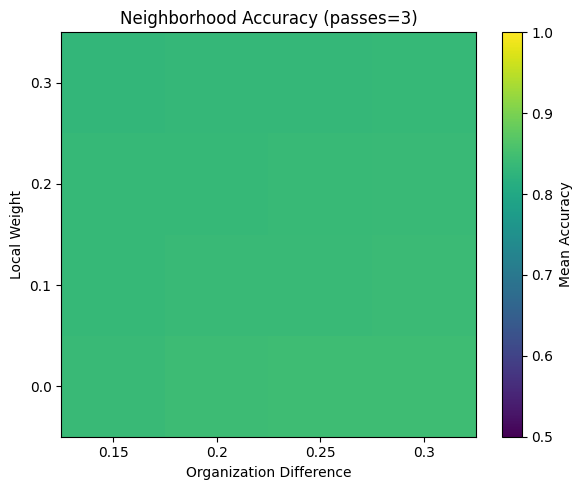

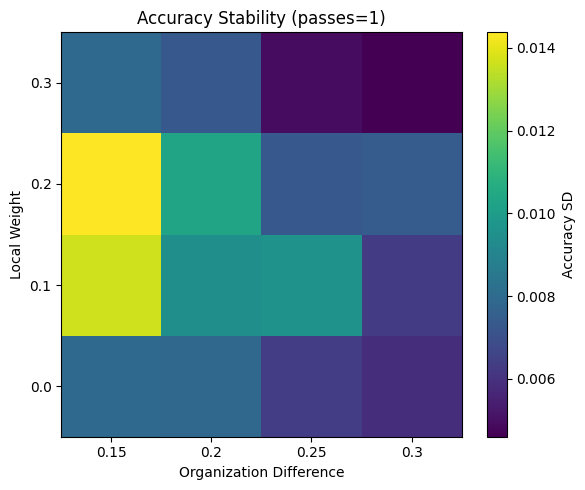

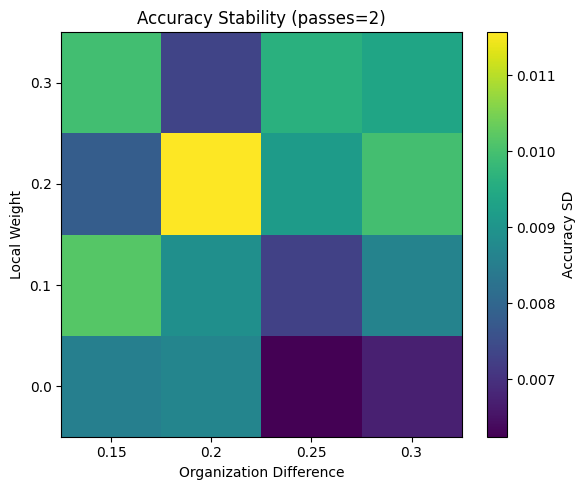

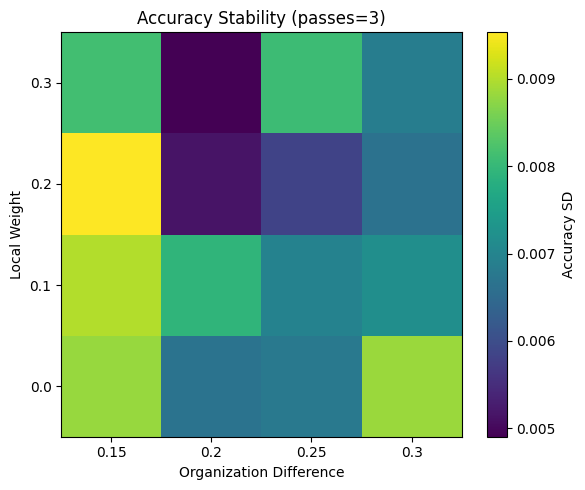

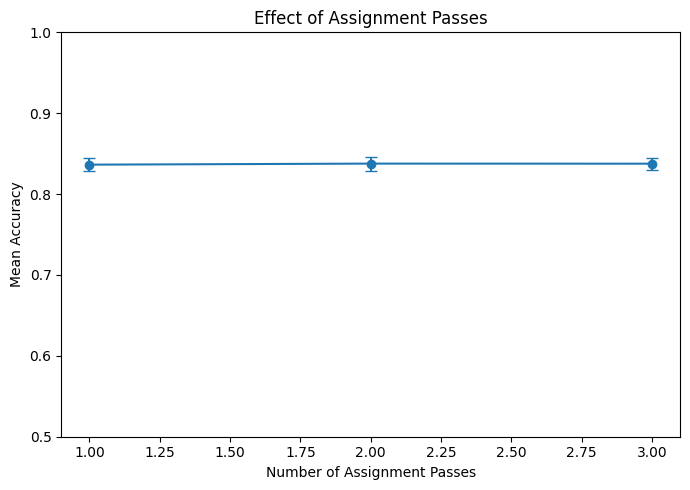

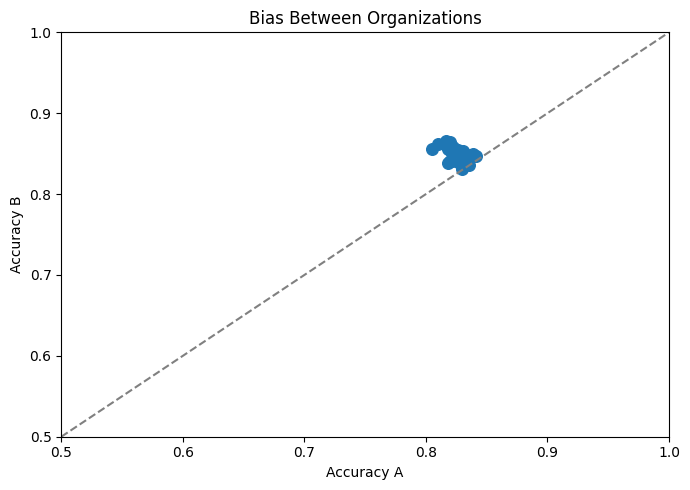

In [ ]:
summary = plot_parameter_sweep(sweep_results)

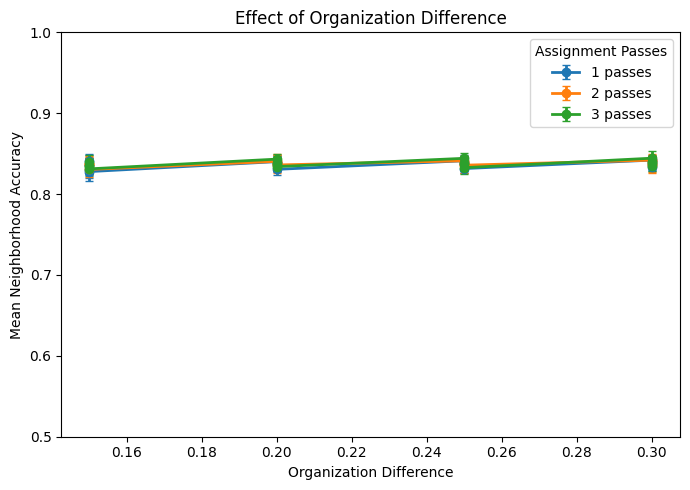

In [42]:
####################################################
# Figure 5
# Organization Difference
####################################################

plt.figure(figsize=(7,5))

for passes in sorted(summary.n_passes.unique()):

    subset = (
        summary
        .query("n_passes == @passes")
        .sort_values("organization_difference")
    )

    plt.errorbar(
        subset.organization_difference,
        subset.mean_accuracy,
        yerr=subset.std_accuracy,
        marker="o",
        linewidth=2,
        capsize=3,
        label=f"{passes} passes",
    )

plt.xlabel("Organization Difference")

plt.ylabel("Mean Neighborhood Accuracy")

plt.title("Effect of Organization Difference")

plt.ylim(0.5,1.0)

plt.legend(title="Assignment Passes")

plt.tight_layout()

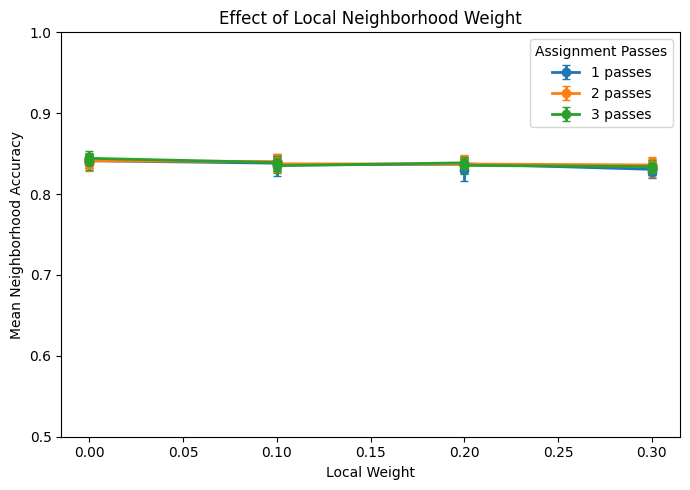

In [43]:
####################################################
# Figure 6
# Local Weight
####################################################

plt.figure(figsize=(7,5))

for passes in sorted(summary.n_passes.unique()):

    subset = (
        summary
        .query("n_passes == @passes")
        .sort_values("local_weight")
    )

    plt.errorbar(
        subset.local_weight,
        subset.mean_accuracy,
        yerr=subset.std_accuracy,
        marker="o",
        linewidth=2,
        capsize=3,
        label=f"{passes} passes",
    )

plt.xlabel("Local Weight")

plt.ylabel("Mean Neighborhood Accuracy")

plt.title("Effect of Local Neighborhood Weight")

plt.ylim(0.5,1.0)

plt.legend(title="Assignment Passes")

plt.tight_layout()

In [44]:
best = (
    summary
    .sort_values("mean_accuracy", ascending=False)
    .head(10)
)

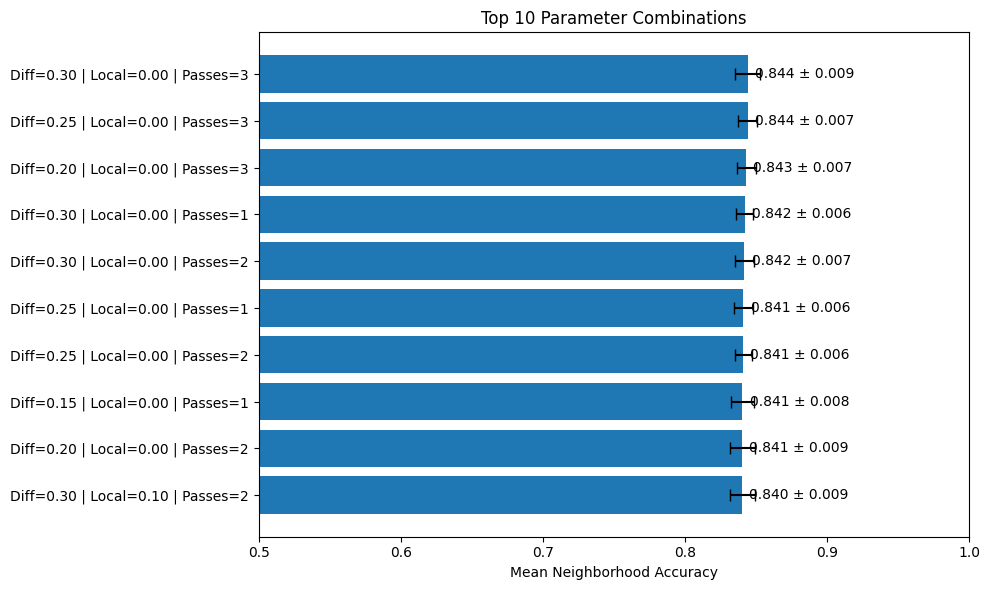

In [46]:
####################################################
# Figure 7
# Top parameter combinations
####################################################

best = (
    summary
    .sort_values(
        "mean_accuracy",
        ascending=False
    )
    .head(10)
    .copy()
)

# Create readable labels
labels = [
    (
        f"Diff={row.organization_difference:.2f} | "
        f"Local={row.local_weight:.2f} | "
        f"Passes={int(row.n_passes)}"
    )
    for _, row in best.iterrows()
]

plt.figure(figsize=(10,6))

bars = plt.barh(
    range(len(best)),
    best.mean_accuracy,
    xerr=best.std_accuracy,
    capsize=4,
)

plt.yticks(
    range(len(best)),
    labels,
    fontsize=10,
)

plt.xlabel("Mean Neighborhood Accuracy")

plt.title("Top 10 Parameter Combinations")

plt.xlim(0.5,1.0)

# Highest-performing parameter set at the top
plt.gca().invert_yaxis()

####################################################
# Write values on the bars
####################################################

for i, (_, row) in enumerate(best.iterrows()):

    plt.text(
        row.mean_accuracy + 0.005,
        i,
        f"{row.mean_accuracy:.3f} ± {row.std_accuracy:.3f}",
        va="center",
        fontsize=10,
    )

plt.tight_layout()

Try to figure out where the errors are.

In [80]:
from sklearn.decomposition import PCA

def diagnose_simulation(df):
    """
    Generate diagnostic plots for a simulated tissue.

    Parameters
    ----------
    df : pandas.DataFrame
        Output of run_neighborhood_finder().
    """

    plot_df = df.copy()

    from matplotlib.lines import Line2D

    def make_legend(
        handles,
        title=None,
        figsize=(2.5,2),
        fontsize=9,
        ncols=1,
        columnspacing=0.8,
        handletextpad=0.4,
    ):
        fig, ax = plt.subplots(figsize=figsize, dpi=300)
        ax.axis("off")

        ax.legend(
            handles=handles,
            title=title,
            frameon=False,
            loc="center",
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncols=ncols,
            columnspacing=columnspacing,
            handletextpad=handletextpad,
        )

        plt.tight_layout()
        plt.show()

    ####################################################
    # Correct classifications
    ####################################################

    plot_df["Correct"] = (
        plot_df["Neighborhood"]
        == plot_df["true_organization"]
    )

    ####################################################
    # Figure 1
    # Ground truth organizations
    ####################################################

    plt.figure(figsize=(6,6))

    colors = {
        "A": "tab:blue",
        "B": "tab:orange",
    }

    for org in ["A","B"]:

        subset = plot_df[
            plot_df.true_organization == org
        ]

        plt.scatter(
            subset.x,
            subset.y,
            s=5,
            color=colors[org],
        )

    plt.gca().invert_yaxis()
    plt.title("Ground Truth Organizations")
    plt.tight_layout()
    plt.show()

    legend_handles = [
        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor='tab:blue',
            markersize=6,
            label='Organization A'
        ),
        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor='tab:orange',
            markersize=6,
            label='Organization B'
        ),
    ]

    make_legend(
        legend_handles,
        title="Ground Truth",
        figsize=(2.5,1.5)
    )

    ####################################################
    # Figure 1.5
    # Cell types
    ####################################################

    plt.figure(figsize=(6,6))

    unique_cell_types = np.sort(plot_df.cell_type.unique())

    cmap = plt.cm.get_cmap(
        "tab20",
        len(unique_cell_types)
    )

    color_map = {
        ct: cmap(i)
        for i, ct in enumerate(unique_cell_types)
    }

    for ct in unique_cell_types:

        subset = plot_df[
            plot_df.cell_type == ct
        ]

        plt.scatter(
            subset.x,
            subset.y,
            s=5,
            color=color_map[ct],
        )

    plt.gca().invert_yaxis()
    plt.title("Cell Types")
    plt.tight_layout()
    plt.show()

    legend_handles = [
        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=color_map[ct],
            markersize=6,
            label=str(ct)
        )
        for ct in unique_cell_types
    ]

    make_legend(
        legend_handles,
        title="Cell Type",
        figsize=(2.5,4),
        ncols = 5,
        columnspacing=0.2
    )
        
    ####################################################
    # Figure 2
    # Recovered neighborhoods
    ####################################################

    plt.figure(figsize=(6,6))

    for neigh in ["A","B"]:

        subset = plot_df[
            plot_df.Neighborhood == neigh
        ]

        plt.scatter(
            subset.x,
            subset.y,
            s=5,
            color=colors[neigh],
        )

    plt.gca().invert_yaxis()
    plt.title("Recovered Neighborhoods")
    plt.tight_layout()
    plt.show()

    legend_handles = [
        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor='tab:blue',
            markersize=6,
            label='Neighborhood A'
        ),
        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor='tab:orange',
            markersize=6,
            label='Neighborhood B'
        ),
    ]

    make_legend(
        legend_handles,
        title="Recovered",
        figsize=(2.5,1.5)
    )

    ####################################################
    # Figure 3
    # Classification errors
    ####################################################

    accuracy = plot_df["Correct"].mean()

    plt.figure(figsize=(6,6))

    plt.scatter(
        plot_df.loc[plot_df.Correct,"x"],
        plot_df.loc[plot_df.Correct,"y"],
        c="lightgray",
        s=4,
    )

    plt.scatter(
        plot_df.loc[~plot_df.Correct,"x"],
        plot_df.loc[~plot_df.Correct,"y"],
        c="red",
        s=8,
    )

    plt.gca().invert_yaxis()

    plt.title("Classification Errors")

    plt.tight_layout()
    plt.show()

    legend_handles = [
        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor='lightgray',
            markersize=6,
            label='Correct'
        ),
        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor='red',
            markersize=6,
            label='Incorrect'
        ),
        Line2D(
            [0],[0],
            color='none',
            label=f'Accuracy = {accuracy:.1%}'
        )
    ]

    make_legend(
        legend_handles,
        title="Classification",
        figsize=(3,2)
    )

    ####################################################
    # Figure 4
    # Cell-type composition
    ####################################################

    composition = pd.crosstab(
        plot_df.true_organization,
        plot_df.cell_type,
        normalize="index"
    )

    plt.figure(figsize=(8,4))

    composition.T.plot(
        kind="bar",
        ax=plt.gca()
    )

    plt.ylabel("Fraction")

    plt.title("Cell-type Composition by Organization")

    plt.tight_layout()

    ####################################################
    # Figure 5
    # PCA of neighborhood vectors
    ####################################################

    if "neighborhood_vectors" in df.attrs:

        X = df.attrs["neighborhood_vectors"]

        embedding = PCA(
            n_components=2
        ).fit_transform(X)

        plt.figure(figsize=(6,6))

        plt.scatter(
            embedding[:,0],
            embedding[:,1],
            c=plot_df.true_organization.map({
                "A":"tab:blue",
                "B":"tab:orange"
            }),
            s=5,
            alpha=0.6,
        )

        plt.xlabel("PC1")

        plt.ylabel("PC2")

        plt.title("Neighborhood Vector PCA")

        plt.tight_layout()

        make_legend(
        [
            Line2D([0],[0], marker='o', color='w',
                markerfacecolor='tab:blue',
                markersize=6,
                label='Organization A'),
            Line2D([0],[0], marker='o', color='w',
                markerfacecolor='tab:orange',
                markersize=6,
                label='Organization B')
        ],
        title="Organization",
        figsize=(2.5,1.5)
    )

    ####################################################
    # Figure 6
    # Accuracy vs distance from border
    ####################################################

    if "border_x" in df.attrs:
        border_x = df.attrs["border_x"]
    else:
        border_x = (
            plot_df["x"].min()
            + plot_df["x"].max()
        ) / 2

    plot_df["distance_from_border"] = np.abs(
        plot_df["x"] - border_x
    )

    bins = np.linspace(
        0,
        plot_df["distance_from_border"].max(),
        20
    )

    plot_df["distance_bin"] = pd.cut(
        plot_df["distance_from_border"],
        bins=bins,
        include_lowest=True,
    )

    distance_summary = (
        plot_df
        .groupby("distance_bin", observed=True)
        .agg(
            mean_distance=("distance_from_border","mean"),
            accuracy=("Correct","mean"),
            n=("Correct","size"),
        )
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(8,5))

    ax1.plot(
        distance_summary.mean_distance,
        distance_summary.accuracy,
        marker="o",
        linewidth=2,
    )

    ax1.set_xlabel("Distance from Organization Boundary")

    ax1.set_ylabel("Neighborhood Accuracy")

    ax1.set_ylim(0.5,1.02)

    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()

    width = (
        distance_summary.mean_distance.max()
        / 25
    )

    ax2.bar(
        distance_summary.mean_distance,
        distance_summary.n,
        width=width,
        alpha=0.2,
    )

    ax2.set_ylabel("Cells per Bin")

    plt.title("Neighborhood Accuracy vs Distance from Boundary")

    plt.tight_layout()

    ####################################################
    # Figure 7
    # Confusion matrix
    ####################################################

    cm = pd.crosstab(
        plot_df.true_organization,
        plot_df.Neighborhood
    )

    print("\nConfusion Matrix\n")

    display(cm)

    ####################################################
    # Summary
    ####################################################

    accuracy = plot_df["Correct"].mean()

    accuracy_A = (
        plot_df.loc[
            plot_df.true_organization=="A",
            "Correct"
        ].mean()
    )

    accuracy_B = (
        plot_df.loc[
            plot_df.true_organization=="B",
            "Correct"
        ].mean()
    )

    print(f"\nOverall Accuracy : {accuracy:.3f}")
    print(f"Accuracy A       : {accuracy_A:.3f}")
    print(f"Accuracy B       : {accuracy_B:.3f}")

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\1514290552.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\2217017118.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(



Confusion Matrix



Neighborhood,A,B
true_organization,,
A,1410,271
B,261,1398



Overall Accuracy : 0.841
Accuracy A       : 0.839
Accuracy B       : 0.843


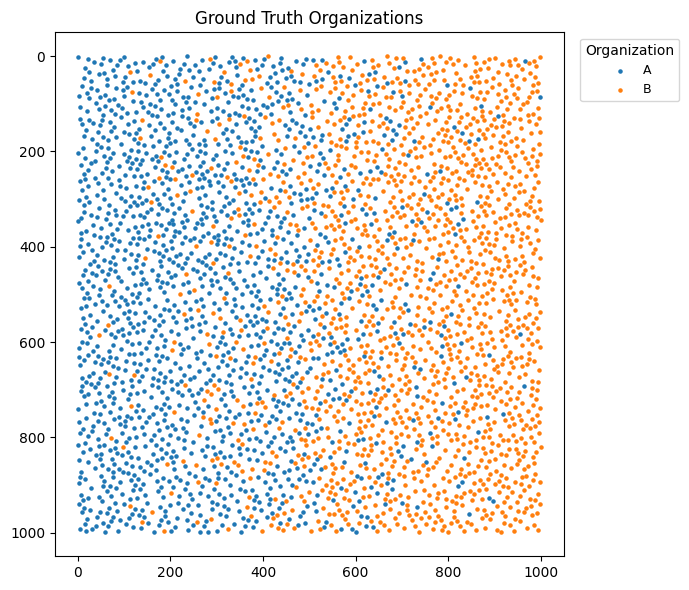

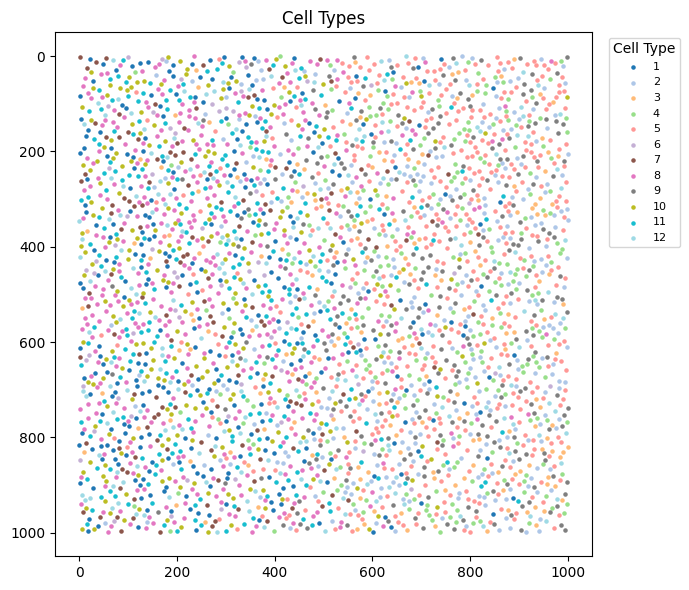

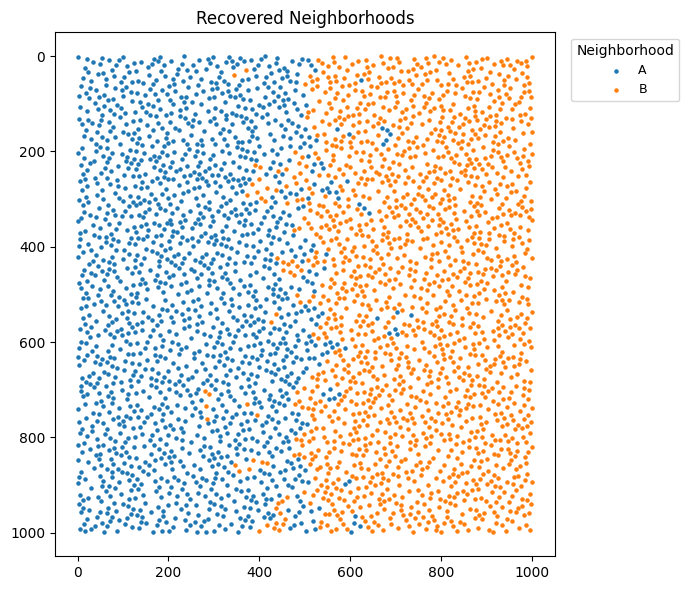

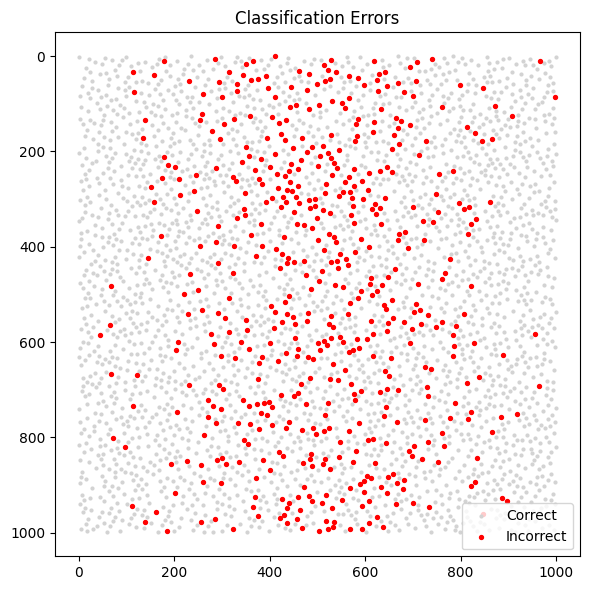

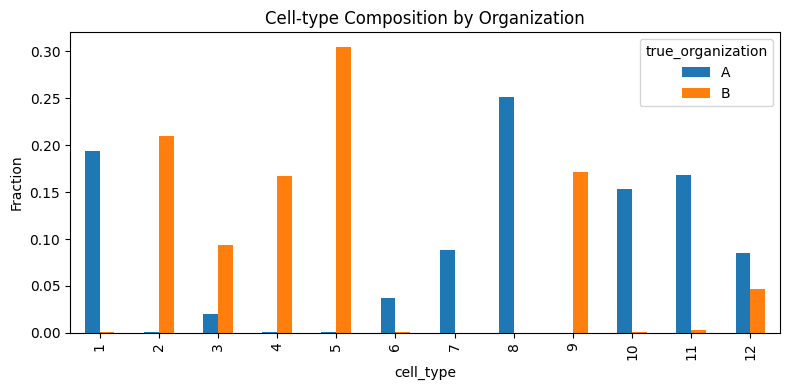

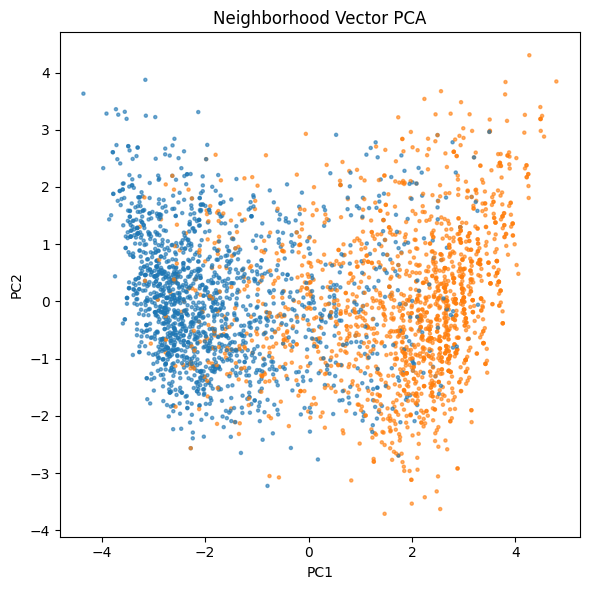

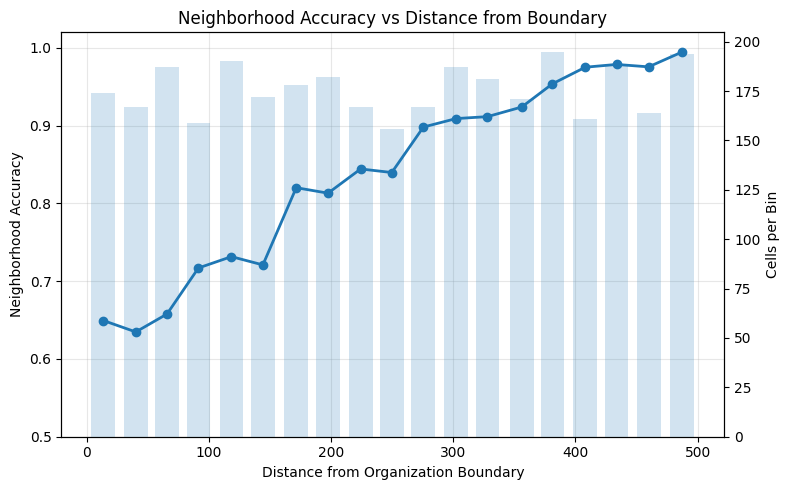

In [68]:
sim = simulate_tissue(
    organization_difference=0.30,
    local_weight=0.0,
    n_passes=2,
    seed=0,
)

sim = run_neighborhood_finder(sim)

diagnose_simulation(sim)

FAST Simulation

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\1514290552.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


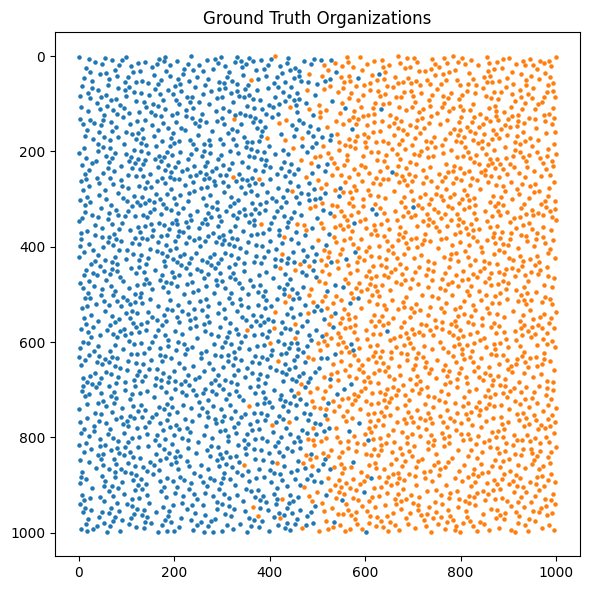

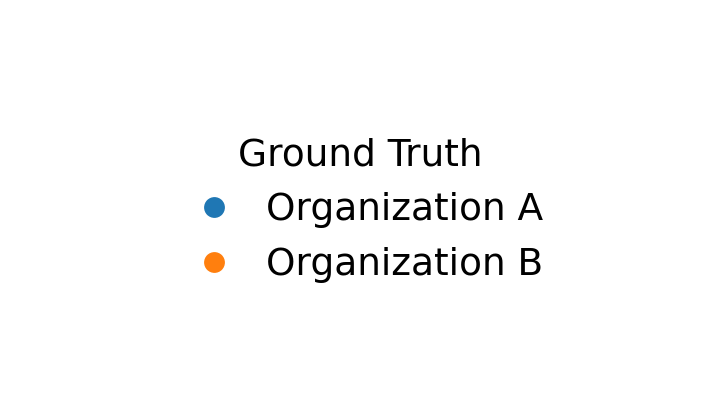

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\1520471378.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(


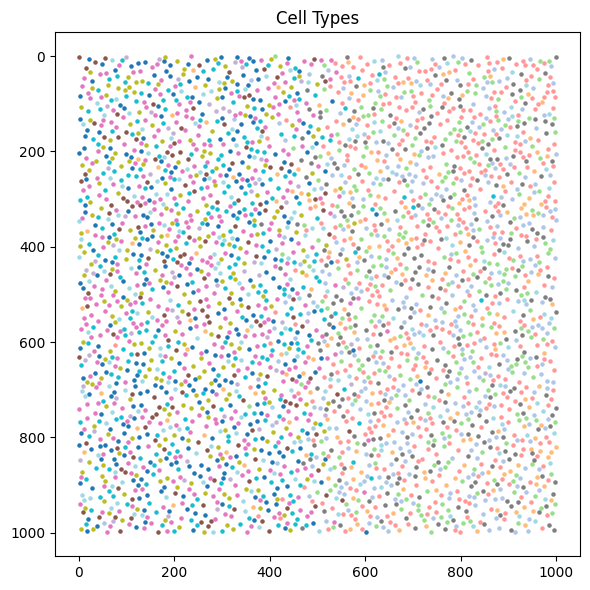

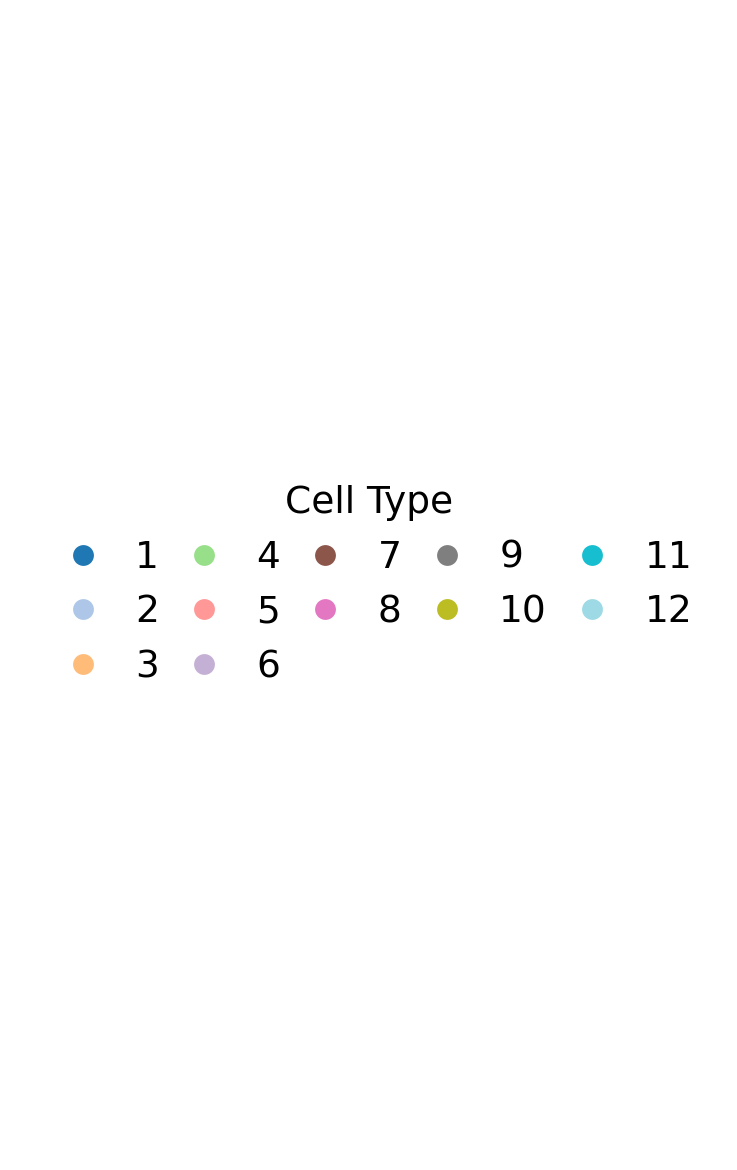

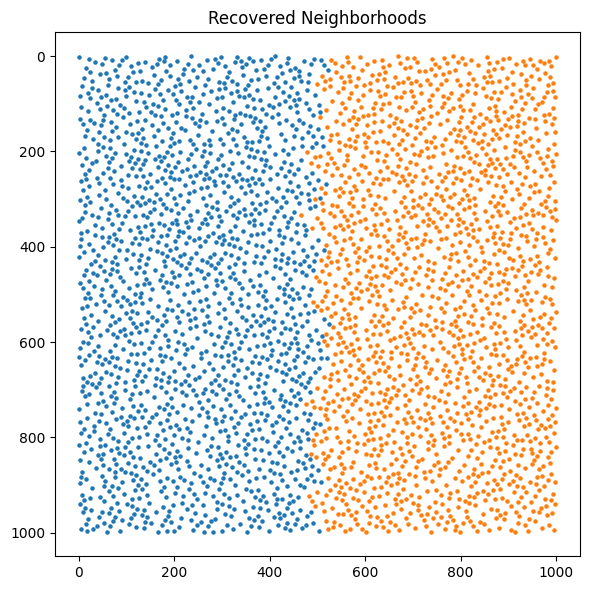

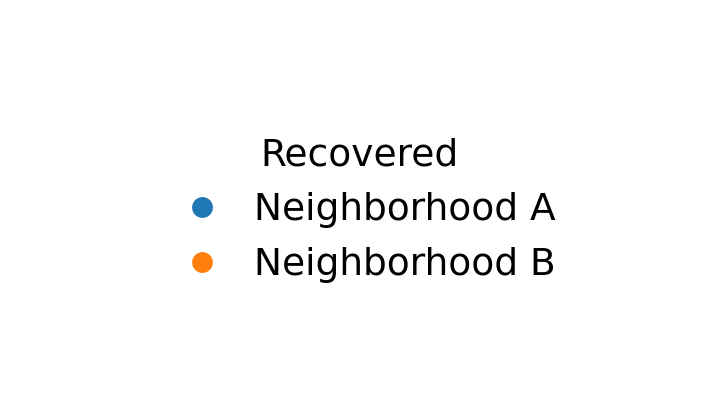

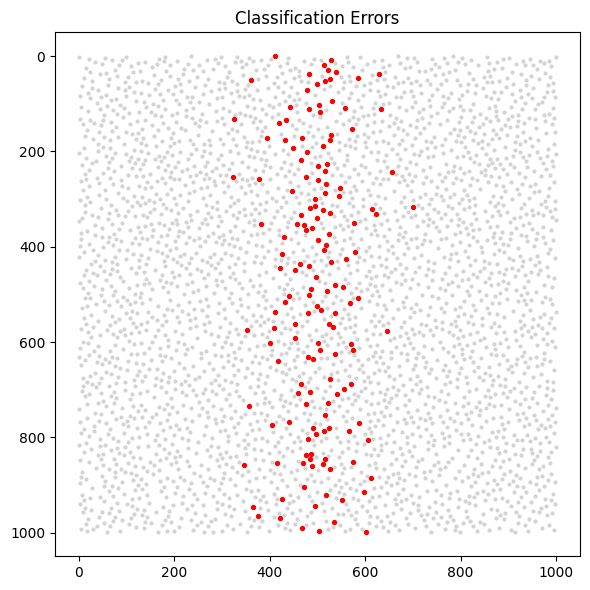

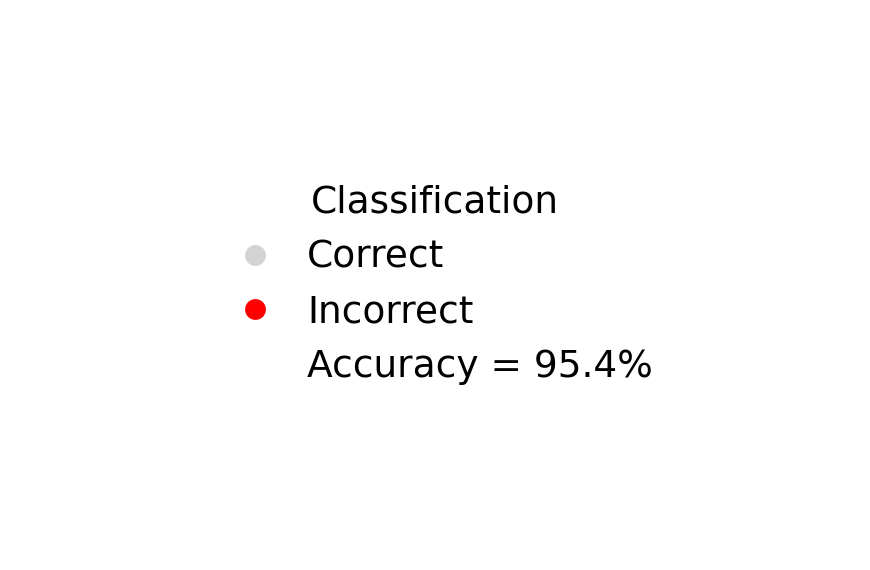

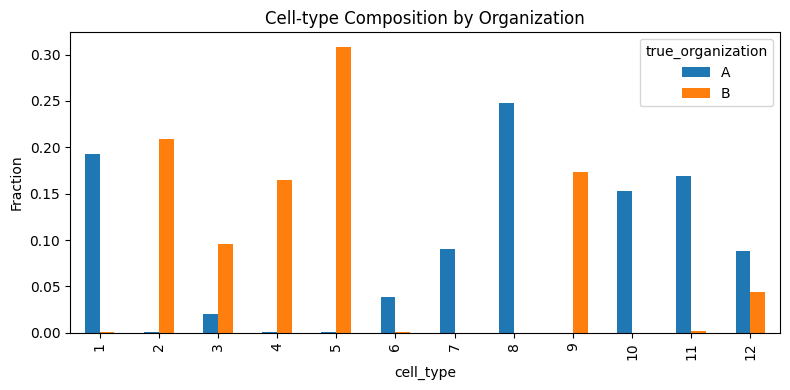

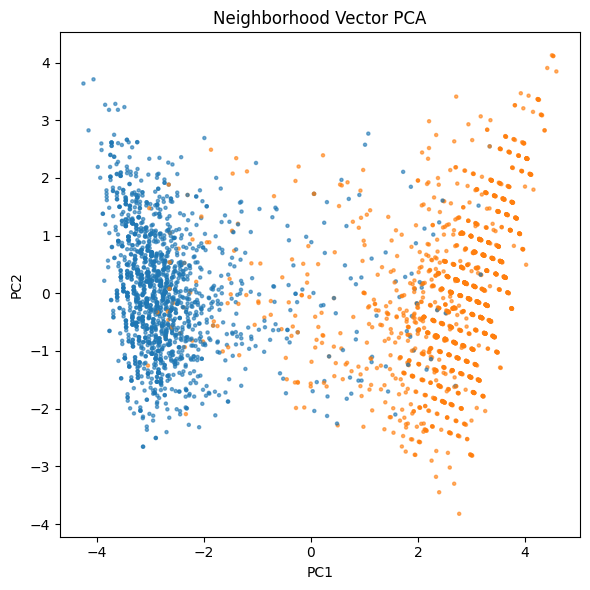

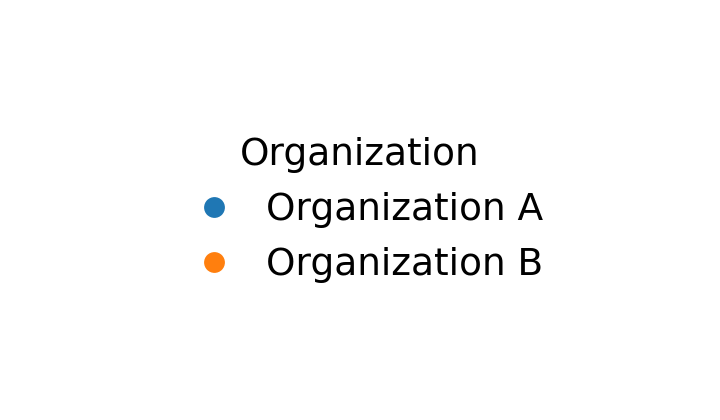


Confusion Matrix



Neighborhood,A,B
true_organization,,
A,1583,75
B,77,1605



Overall Accuracy : 0.954
Accuracy A       : 0.955
Accuracy B       : 0.954


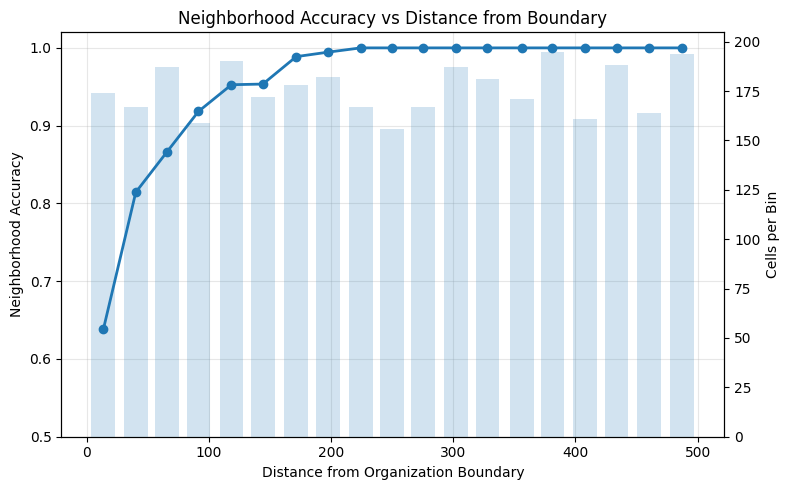

In [81]:
fast = simulate_tissue(
    organization_mixing_width=40,#slow=250, medium=120, fast=40
    organization_difference=0.30,
    local_weight=0.0,
    n_passes=2,
    seed=0,
)

fast = run_neighborhood_finder(fast)

diagnose_simulation(fast)

fast.to_csv(
    r"Z:\MINGLE\Reviewer Response\Code\R1.5\synthetic_tissue_fast.csv",
    index=False,
)

MEDIUM

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\1514290552.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


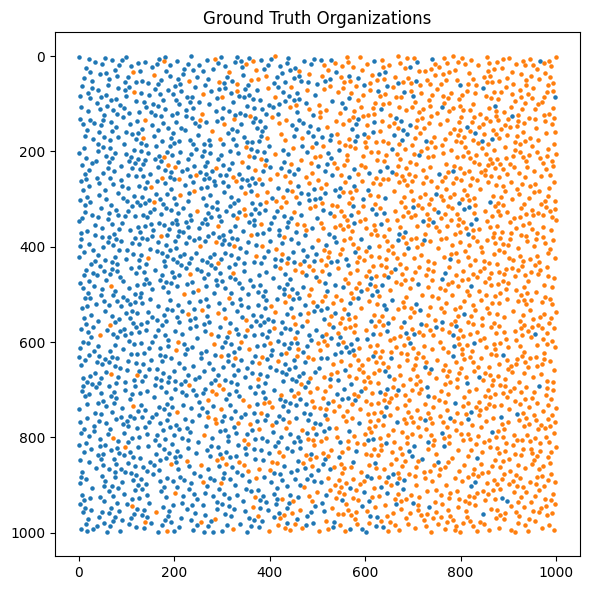

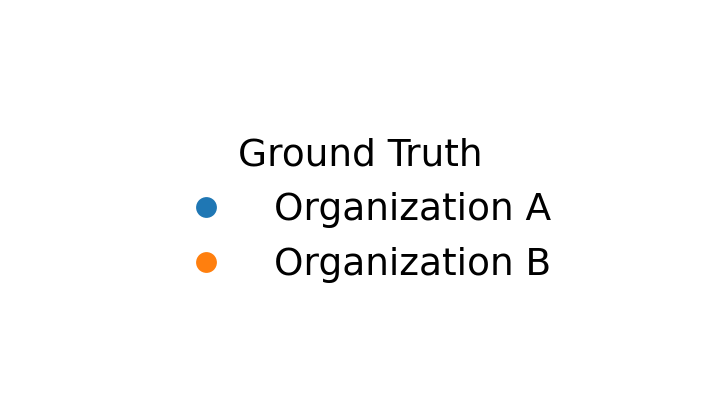

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\43185162.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(


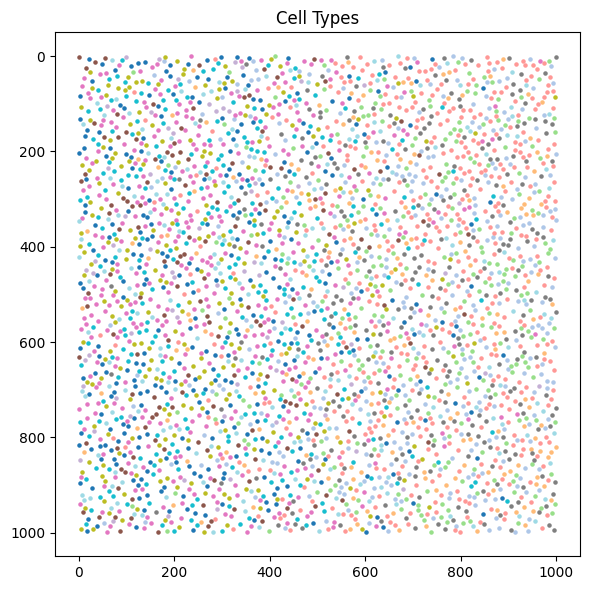

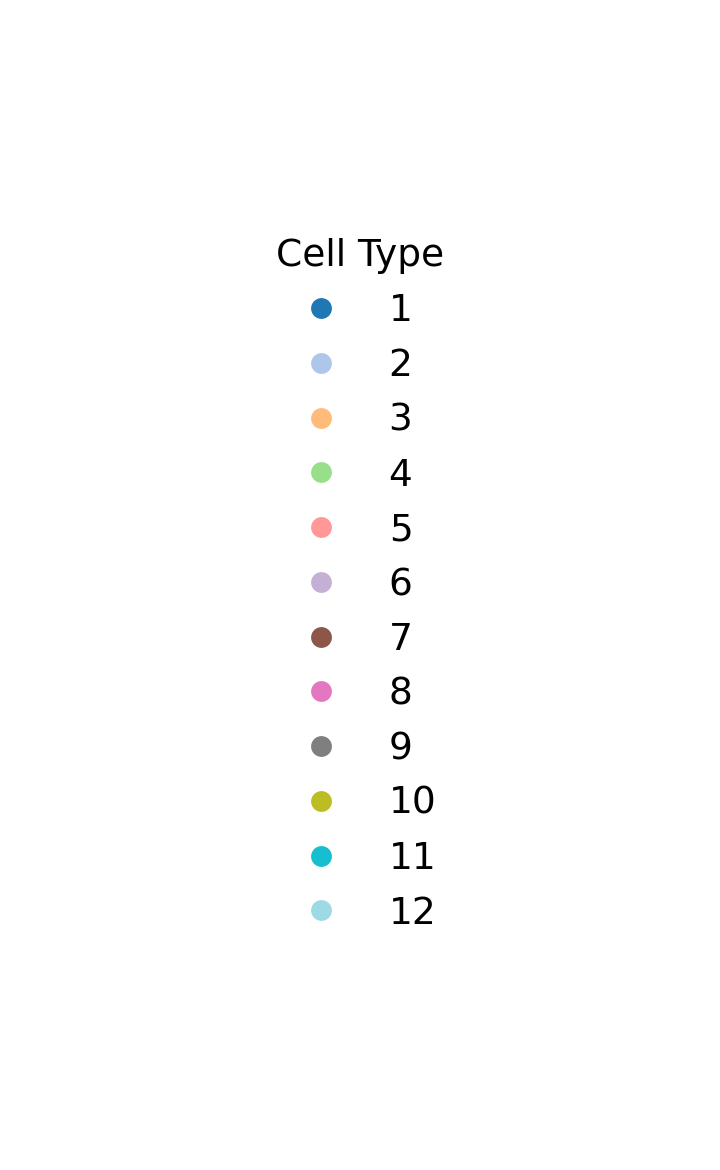

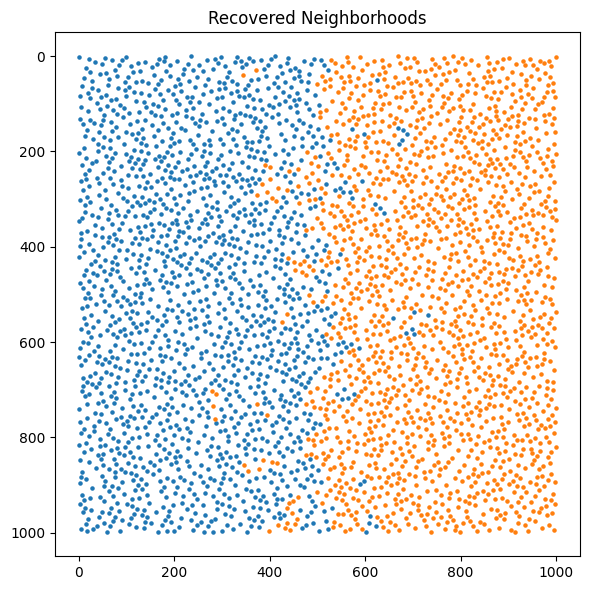

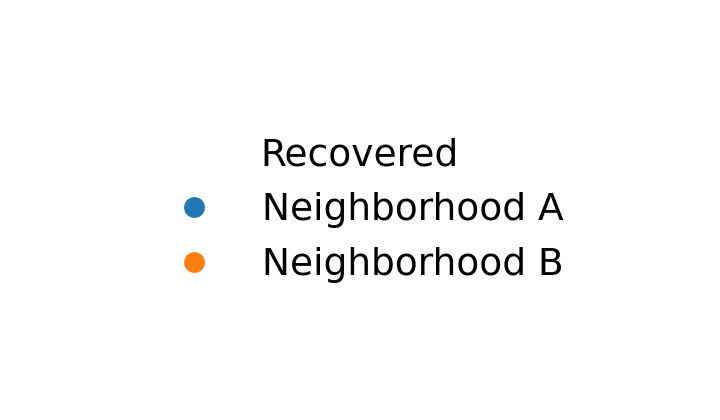

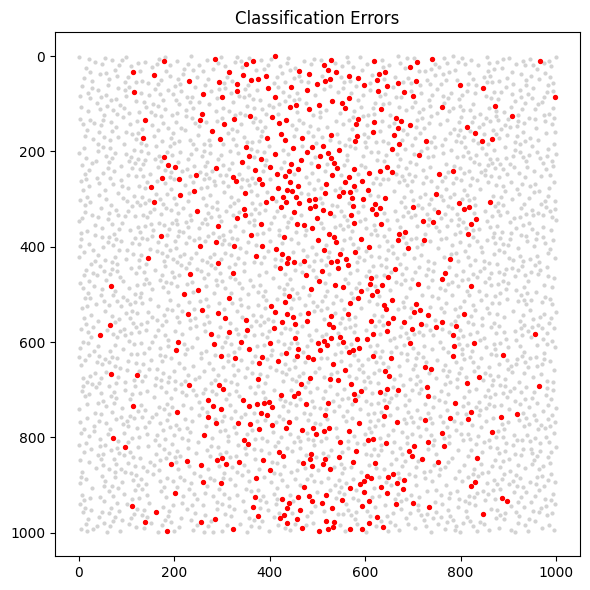

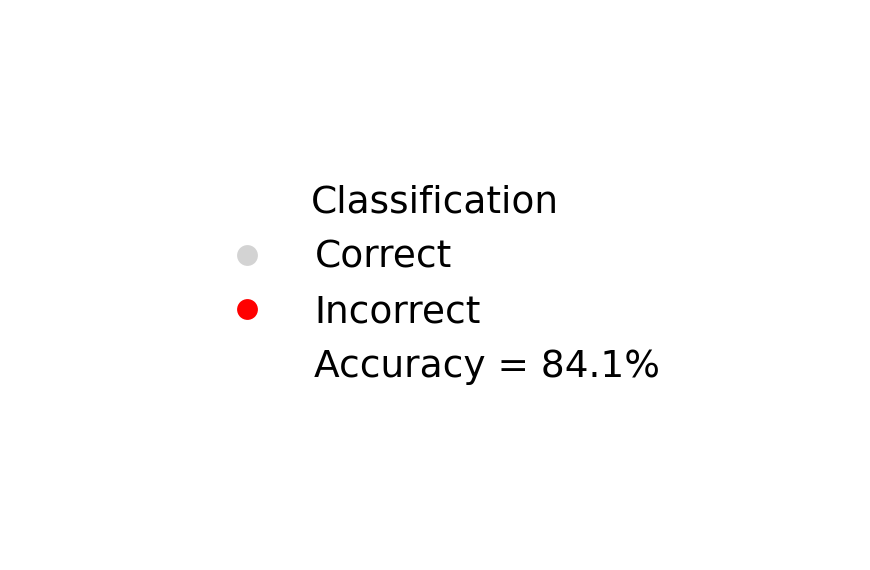

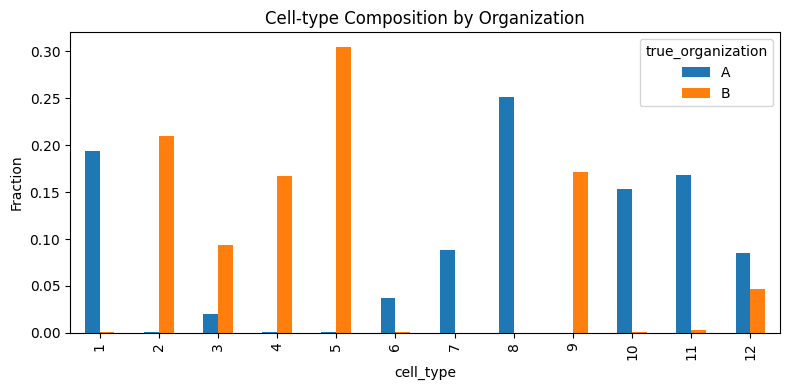

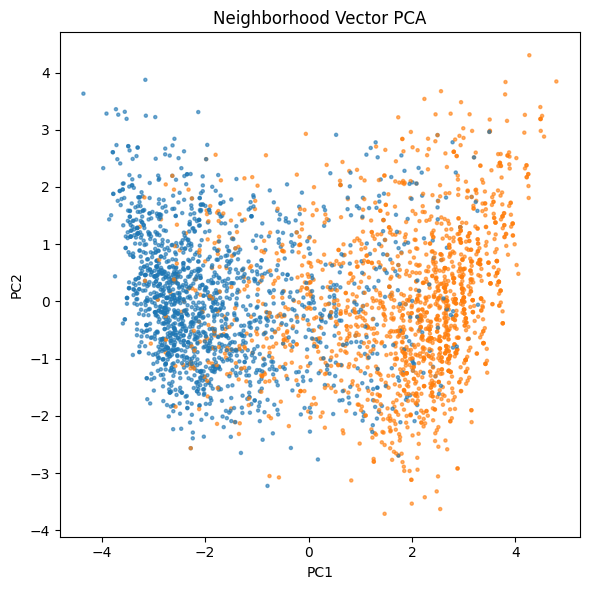

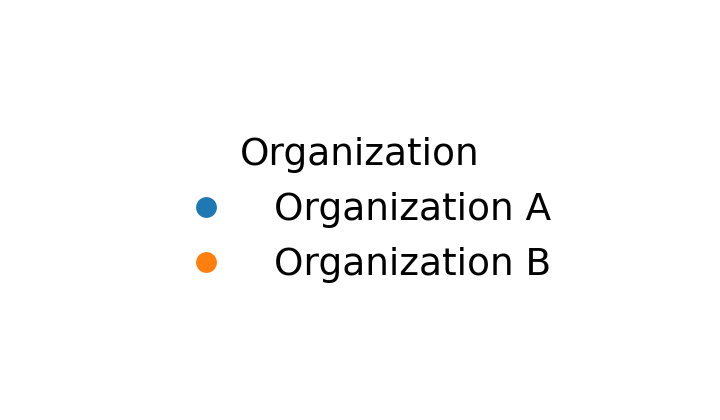


Confusion Matrix



Neighborhood,A,B
true_organization,,
A,1410,271
B,261,1398



Overall Accuracy : 0.841
Accuracy A       : 0.839
Accuracy B       : 0.843


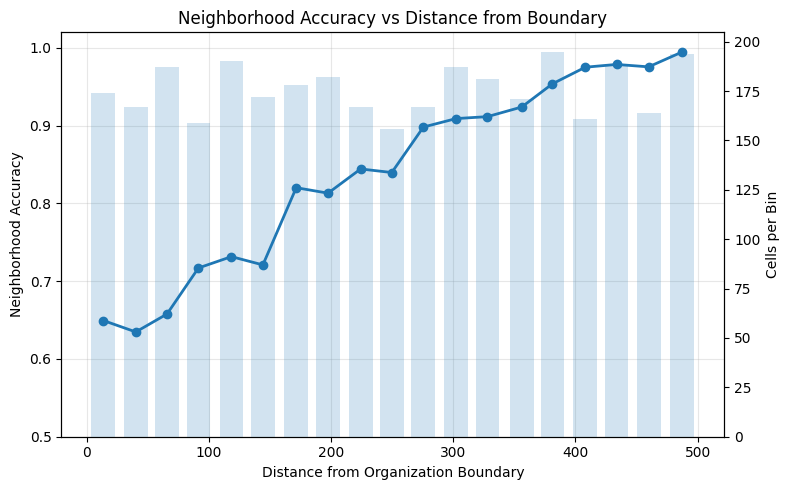

In [74]:
medium = simulate_tissue(
    organization_mixing_width=120,#slow=250, medium=120, fast=40
    organization_difference=0.30,
    local_weight=0.0,
    n_passes=2,
    seed=0,
)

medium = run_neighborhood_finder(medium)

diagnose_simulation(medium)

medium.to_csv(
    r"Z:\MINGLE\Reviewer Response\Code\R1.5\synthetic_tissue_medium.csv",
    index=False,
)

SLOW

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\1514290552.py:40: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points = sampler.random(n_cells)


Starting: 1/1 : 1
Finished: 1/1 (0.01 sec)


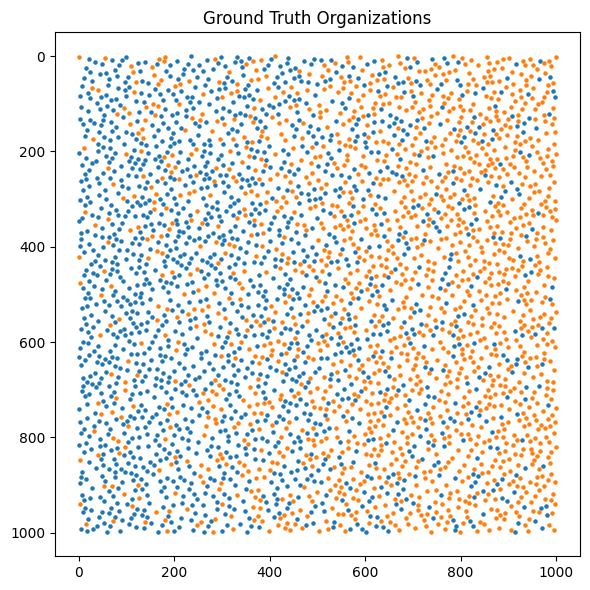

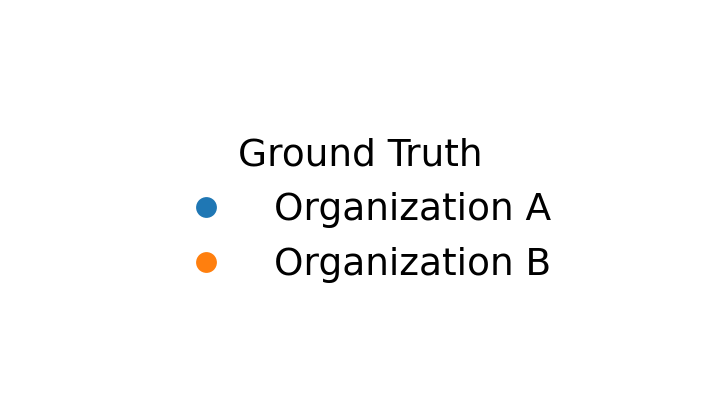

C:\Users\k1van\AppData\Local\Temp\ipykernel_9272\43185162.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(


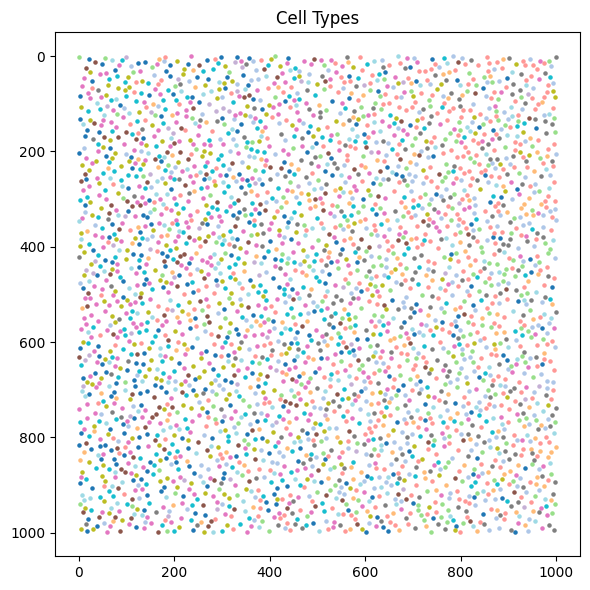

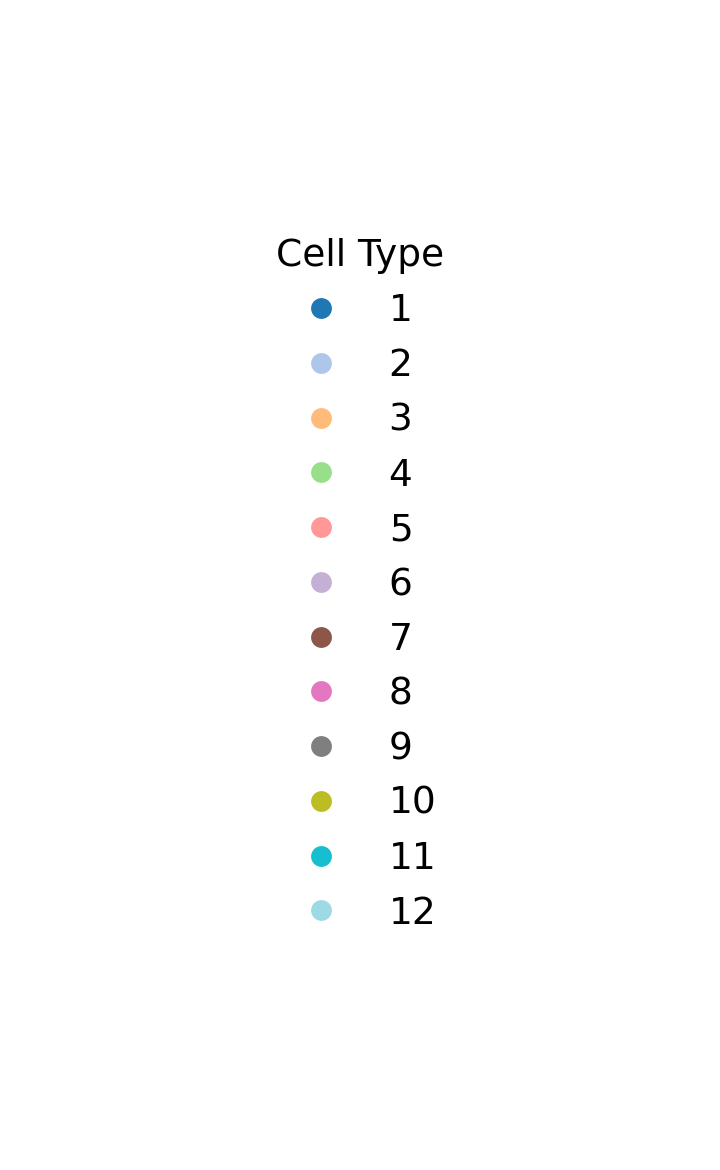

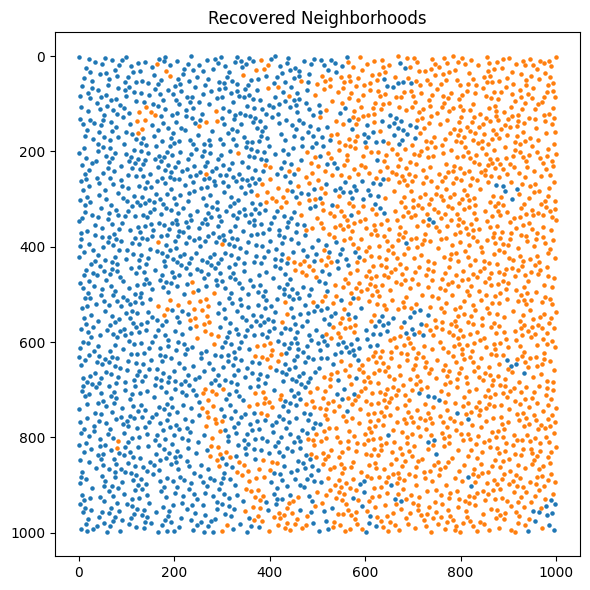

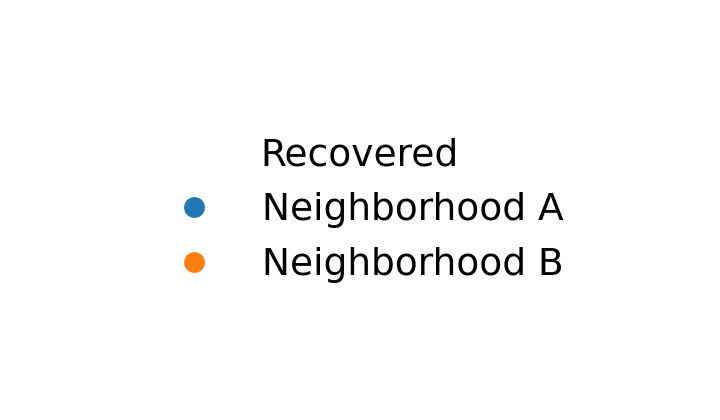

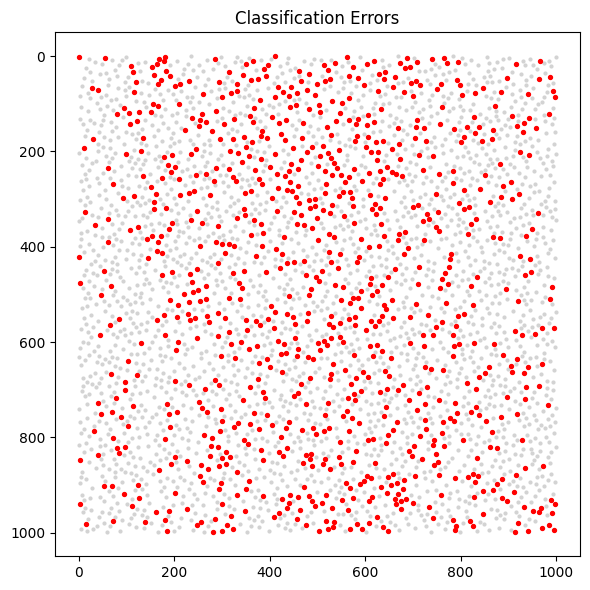

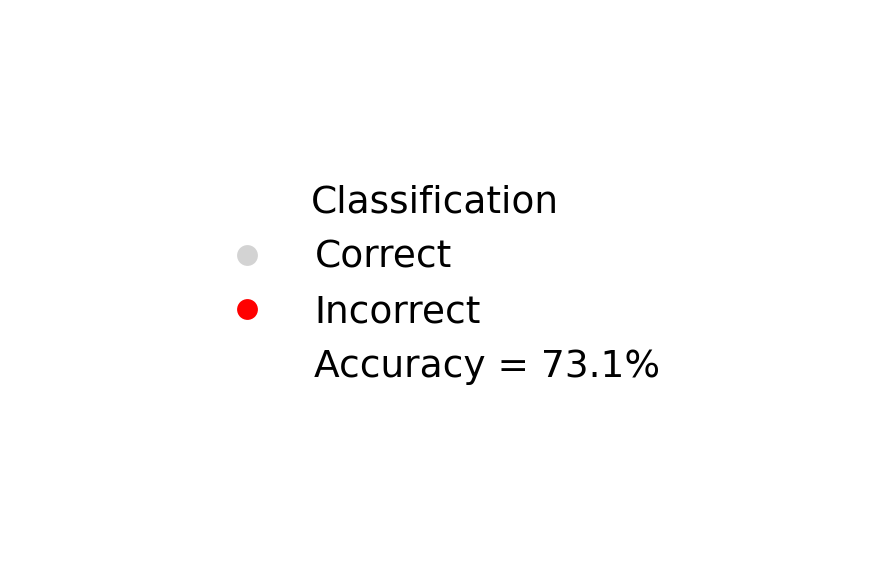

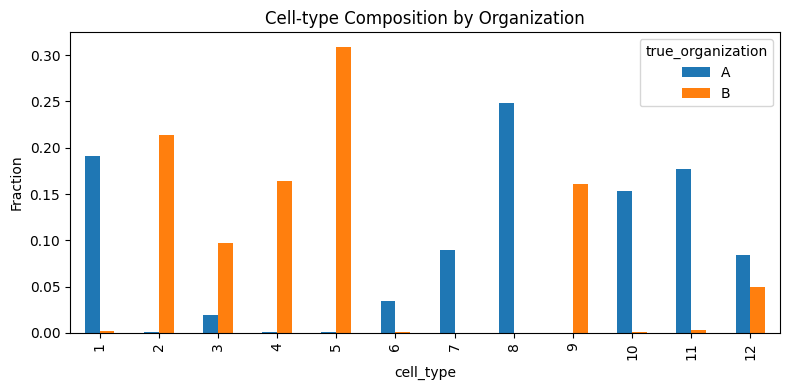

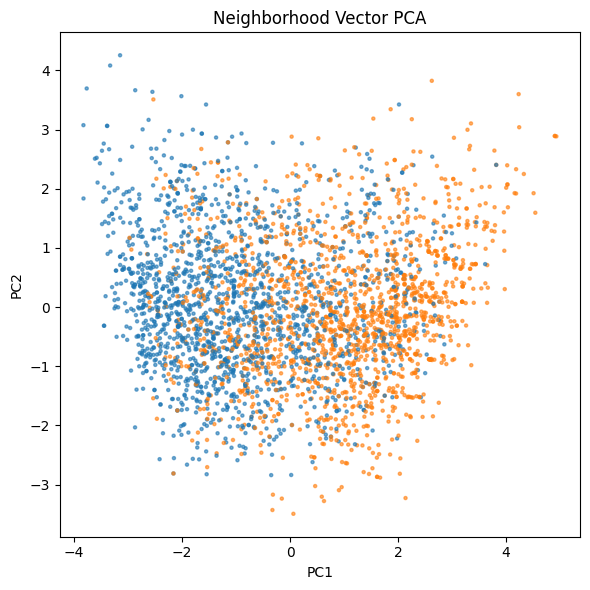

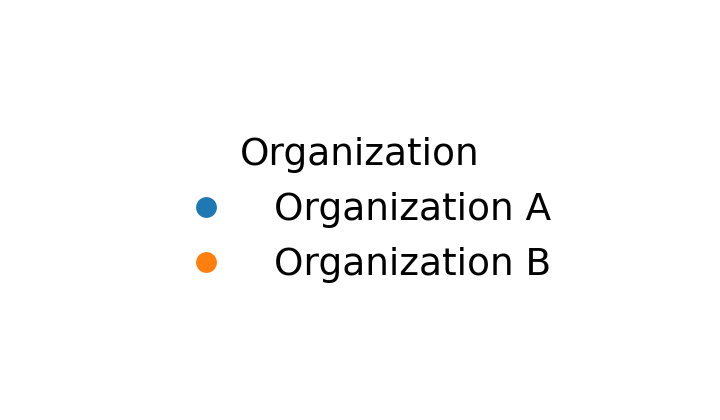


Confusion Matrix



Neighborhood,A,B
true_organization,,
A,1227,464
B,436,1213



Overall Accuracy : 0.731
Accuracy A       : 0.726
Accuracy B       : 0.736


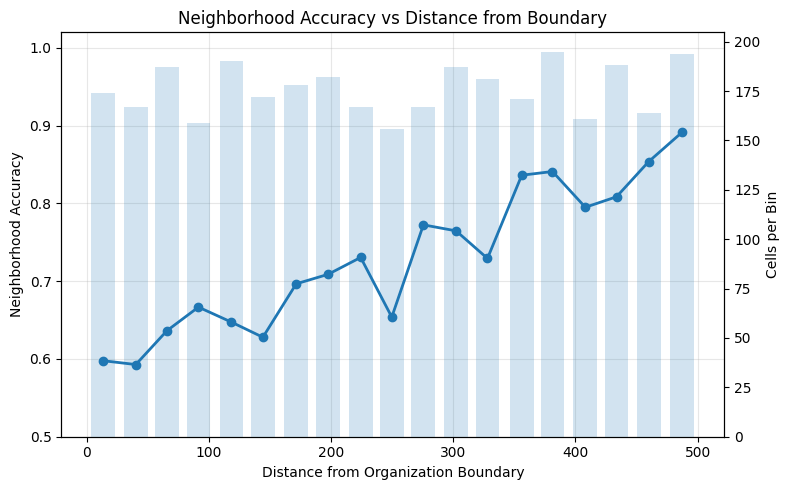

In [75]:
slow = simulate_tissue(
    organization_mixing_width=250,#slow=250, medium=120, fast=40
    organization_difference=0.30,
    local_weight=0.0,
    n_passes=2,
    seed=0,
)

slow = run_neighborhood_finder(slow)

diagnose_simulation(slow)

slow.to_csv(
    r"Z:\MINGLE\Reviewer Response\Code\R1.5\synthetic_tissue_slow.csv",
    index=False,
)